# Subsampled Synthetic Graph EDA

Analyses BiGG runs trained with `--subsample`. Each run produces a directory of `subgraph_N` files.
This notebook examines:
1. Per-subgraph topology (size, density, degree distribution) — checks the K-cap is working
2. Combined graph vs original — same structural and feature fidelity as the standard EDA

In [8]:
import os
import dgl
from dgl import load_graphs
import networkx as nx
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [22]:
# Config
ORG_DATASET = "tolokers"
TASK = "hidden_labels"
# Subsampled run directory — same as SUBDIR in eda.ipynb, but points directly
# to the run directory (the one containing subgraph_* files), not a parent folder.
# Example: "blksize_-1_b_1_lr_0.001_epochs_50_..._sub6_size2000_k10"
RUN_NAME = "blksize_-1_b_1_lr_0.001_epochs_2_noise_0.3_ss_0.0_norm_zscore_bfs_lw_0.1_0.1_hetero_masked_sub5_size500_k10"   # None = auto-select first subsampled run found in the task folder

# Feature comparison mode:
#   True  -> normalise the original features (compare in normalised space)
#   False -> unnormalise the synthetic features (compare in original space)
SHOW_NORMALIZED = True

## Original Graph

In [23]:
PATH = f'../datasets/original/{ORG_DATASET}'
original_graph, _ = load_graphs(PATH)
original_graph = original_graph[0]

print(f"Original: {original_graph.num_nodes()} nodes, {original_graph.num_edges()} edges")
print(f"Anomalies: {original_graph.ndata['label'].tolist().count(1)}")

Original: 11758 nodes, 530758 edges
Anomalies: 2566


## Locate Subsampled Run

In [25]:
task_path = f'../datasets/synthetic/bigg/{ORG_DATASET}/{TASK}'

# Find all subsampled run directories (directories that contain subgraph_* files)
# directly under the task folder — same level as individual graph files in eda.ipynb
run_dirs = sorted([
    f for f in os.listdir(task_path)
    if os.path.isdir(os.path.join(task_path, f))
    and not f.endswith('_combined')
    and any(x.startswith('subgraph_') for x in os.listdir(os.path.join(task_path, f)))
])

print(f"Found {len(run_dirs)} subsampled run(s) in '{TASK}':")
for r in run_dirs:
    n_sg = len([x for x in os.listdir(os.path.join(task_path, r)) if x.startswith('subgraph_')])
    print(f"  {r}  ({n_sg} subgraphs)")

run = RUN_NAME if RUN_NAME else run_dirs[0]
run_path = os.path.join(task_path, run)
print(f"\nAnalysing: {run}")

Found 2 subsampled run(s) in 'hidden_labels':
  blksize_-1_b_1_lr_0.001_epochs_2_noise_0.3_ss_0.0_norm_none_bfs_lw_0.1_0.1_hetero_masked_sub5_size500_k10  (5 subgraphs)
  blksize_-1_b_1_lr_0.001_epochs_2_noise_0.3_ss_0.0_norm_zscore_bfs_lw_0.1_0.1_hetero_masked_sub5_size500_k10  (5 subgraphs)

Analysing: blksize_-1_b_1_lr_0.001_epochs_2_noise_0.3_ss_0.0_norm_zscore_bfs_lw_0.1_0.1_hetero_masked_sub5_size500_k10


## Load Subgraphs

In [26]:
subgraph_files = sorted(
    f for f in os.listdir(run_path) if f.startswith('subgraph_')
)

subgraphs = []
for fname in subgraph_files:
    gs, _ = load_graphs(os.path.join(run_path, fname))
    subgraphs.append(gs[0])

combined = dgl.batch(subgraphs)
print(f"Loaded {len(subgraphs)} subgraphs → combined: {combined.num_nodes()} nodes, {combined.num_edges()} edges")

# Load norm stats if present
norm_stats = None
stats_path = os.path.join(run_path, 'norm_stats.pt')
if os.path.exists(stats_path):
    norm_stats = torch.load(stats_path, weights_only=False)
    print(f"Norm stats loaded: method={norm_stats['method']}")

Loaded 5 subgraphs → combined: 2500 nodes, 53244 edges
Norm stats loaded: method=zscore


In [27]:
subgraph_files = sorted(
    f for f in os.listdir(run_path) if f.startswith('subgraph_')
)

subgraphs = []
for fname in subgraph_files:
    gs, _ = load_graphs(os.path.join(run_path, fname))
    subgraphs.append(gs[0])

combined = dgl.batch(subgraphs)
print(f"Loaded {len(subgraphs)} subgraphs → combined: {combined.num_nodes()} nodes, {combined.num_edges()} edges")

# Load norm stats if present
norm_stats = None
stats_path = os.path.join(run_path, 'norm_stats.pt')
if os.path.exists(stats_path):
    norm_stats = torch.load(stats_path, weights_only=False)
    print(f"Norm stats loaded: method={norm_stats['method']}")

Loaded 5 subgraphs → combined: 2500 nodes, 53244 edges
Norm stats loaded: method=zscore


## Per-Subgraph Summary

In [28]:
rows = []
for i, (fname, sg) in enumerate(zip(subgraph_files, subgraphs)):
    n = sg.num_nodes()
    e = sg.num_edges()
    anom = sg.ndata['label'].tolist().count(1) if 'label' in sg.ndata else 'N/A'
    density = e / (n * (n - 1)) if n > 1 else 0.0
    max_possible_edges = n * (n - 1) / 2
    rows.append({
        'Subgraph': fname,
        'Nodes': n,
        'Edges': e,
        'Anomalies': anom,
        'Density': f'{density:.5f}',
        'Edges / max possible': f'{e / max_possible_edges:.5f}',
    })

# Add combined and original rows
cn = combined.num_nodes(); ce = combined.num_edges()
on = original_graph.num_nodes(); oe = original_graph.num_edges()
rows.append({'Subgraph': '--- COMBINED ---', 'Nodes': cn, 'Edges': ce,
             'Anomalies': combined.ndata['label'].tolist().count(1) if 'label' in combined.ndata else 'N/A',
             'Density': f'{ce / (cn*(cn-1)):.5f}', 'Edges / max possible': ''})
rows.append({'Subgraph': '--- ORIGINAL ---', 'Nodes': on, 'Edges': oe,
             'Anomalies': original_graph.ndata['label'].tolist().count(1),
             'Density': f'{oe / (on*(on-1)):.5f}', 'Edges / max possible': ''})

display(pd.DataFrame(rows).set_index('Subgraph'))

,Nodes,Edges,Anomalies,Density,Edges / max possible
Subgraph,,,,,
subgraph_0,500,10770,167,0.04317,0.08633
subgraph_1,500,10542,173,0.04225,0.08451
subgraph_2,500,10634,166,0.04262,0.08524
subgraph_3,500,10400,169,0.04168,0.08337
subgraph_4,500,10898,163,0.04368,0.08736
--- COMBINED ---,2500,53244,838,0.00852,
--- ORIGINAL ---,11758,530758,2566,0.00384,


## Per-Subgraph Degree Distribution

The K-neighbor cap should bound each subgraph's max degree to ≈ `subsample_k` (for nodes near the BFS frontier). The distribution should be narrow and low compared to the original's power-law tail.

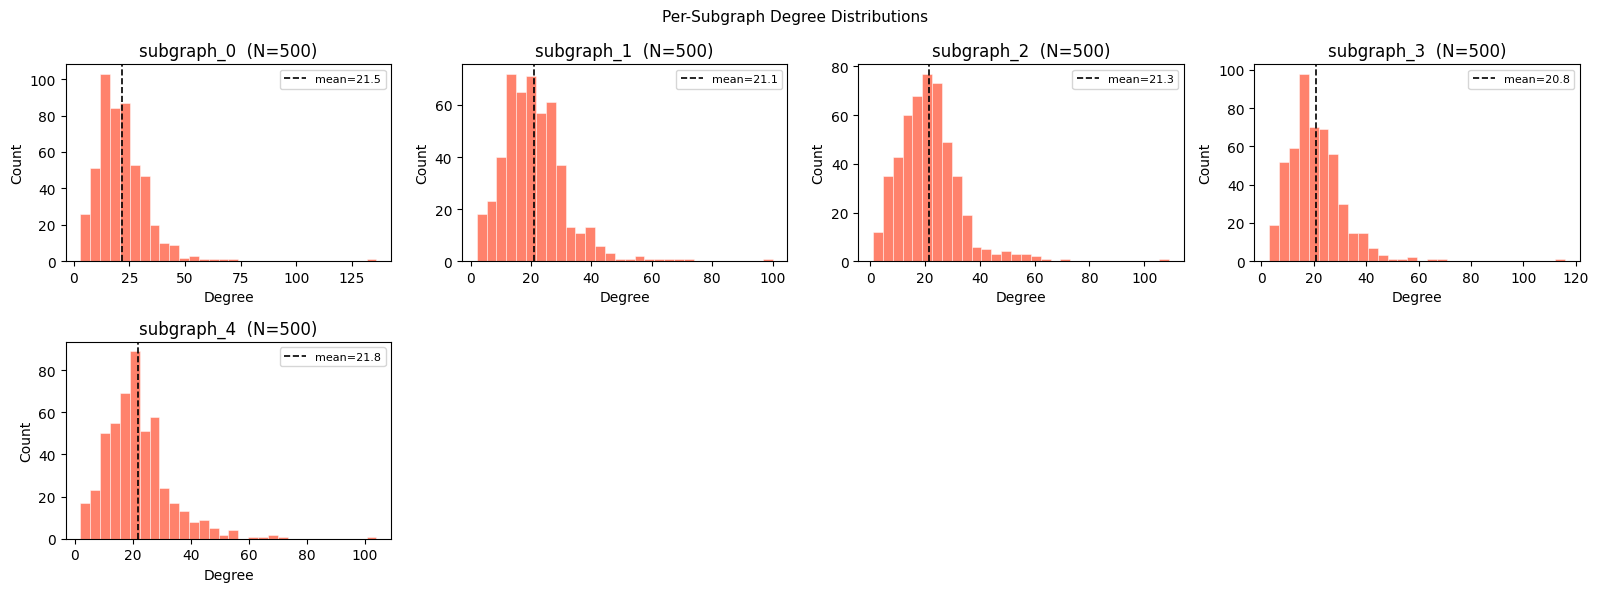

Original  — mean degree: 90.28, max: 2140


In [29]:
org_nx = nx.Graph(original_graph.to_networkx())
org_degrees = [d for _, d in org_nx.degree()]

ncols = min(4, len(subgraphs))
nrows = (len(subgraphs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=False)
axes = np.array(axes).flatten() if len(subgraphs) > 1 else [axes]

for i, sg in enumerate(subgraphs):
    sg_nx = nx.Graph(sg.to_networkx())
    degs = [d for _, d in sg_nx.degree()]
    axes[i].hist(degs, bins=30, color='tomato', alpha=0.8, edgecolor='white', linewidth=0.4)
    axes[i].axvline(np.mean(degs), color='black', linestyle='--', linewidth=1.2,
                    label=f'mean={np.mean(degs):.1f}')
    axes[i].set_title(f'subgraph_{i}  (N={sg.num_nodes()})')
    axes[i].set_xlabel('Degree')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

for j in range(len(subgraphs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-Subgraph Degree Distributions', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Original  — mean degree: {np.mean(org_degrees):.2f}, max: {max(org_degrees)}')

## Combined vs Original — Graph Statistics

Degree statistics:


,Original,Combined Synthetic
Mean,90.28,21.30
Median,32.0,20.0
Max,2140,136


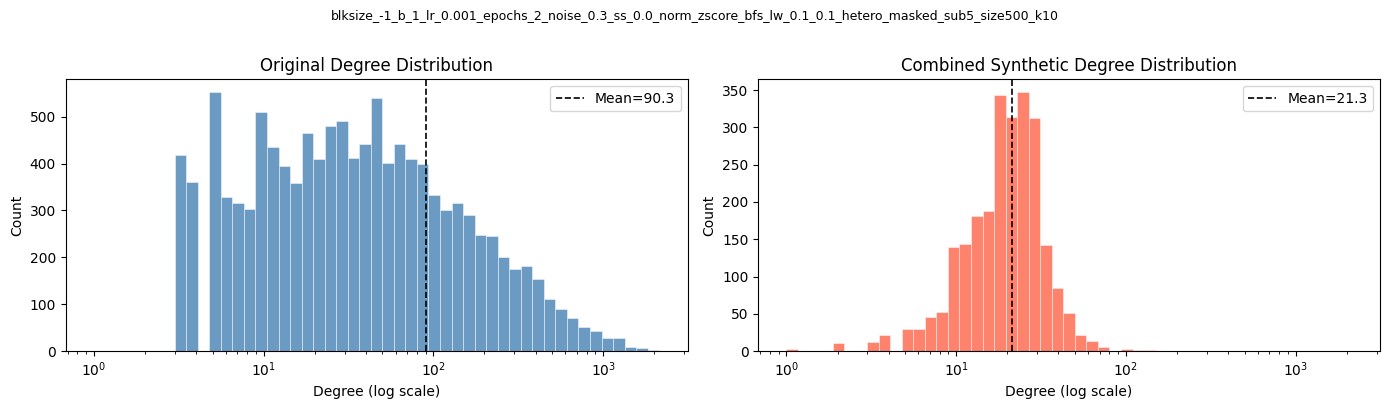

In [30]:
combined_nx = nx.Graph(combined.to_networkx())
comb_degrees = [d for _, d in combined_nx.degree()]

def degree_stats_dict(degrees, label):
    return {
        'Mean': f'{np.mean(degrees):.2f}',
        'Median': f'{np.median(degrees):.1f}',
        'Max': max(degrees),
    }

deg_df = pd.DataFrame({
    'Original': degree_stats_dict(org_degrees, 'org'),
    'Combined Synthetic': degree_stats_dict(comb_degrees, 'syn'),
})
print('Degree statistics:')
display(deg_df)

# Degree distribution overlay
max_deg = max(max(org_degrees), max(comb_degrees))
bins = np.logspace(0, np.log10(max_deg + 1), 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, degrees, label, color in zip(
    axes,
    [org_degrees, comb_degrees],
    ['Original', 'Combined Synthetic'],
    ['steelblue', 'tomato'],
):
    ax.hist(degrees, bins=bins, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_xscale('log')
    ax.set_xlabel('Degree (log scale)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Degree Distribution')
    ax.axvline(np.mean(degrees), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean={np.mean(degrees):.1f}')
    ax.legend()

plt.suptitle(run, fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

Computing clustering coefficients (may be slow for large graphs)...


,Original,Combined Synthetic
Avg clustering coeff,0.5329,0.0675


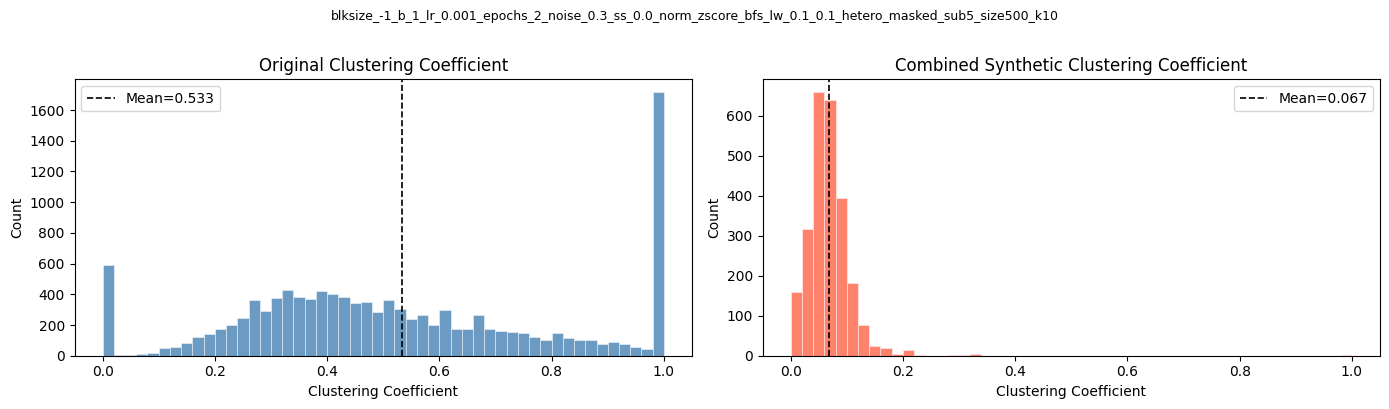

In [31]:
# Clustering coefficient
print('Computing clustering coefficients (may be slow for large graphs)...')

org_cc_avg = nx.average_clustering(org_nx)
comb_cc_avg = nx.average_clustering(combined_nx)

cc_df = pd.DataFrame({
    'Original': {'Avg clustering coeff': f'{org_cc_avg:.4f}'},
    'Combined Synthetic': {'Avg clustering coeff': f'{comb_cc_avg:.4f}'},
})
display(cc_df)

org_cc = list(nx.clustering(org_nx).values())
comb_cc = list(nx.clustering(combined_nx).values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cc_vals, label, color in zip(
    axes,
    [org_cc, comb_cc],
    ['Original', 'Combined Synthetic'],
    ['steelblue', 'tomato'],
):
    ax.hist(cc_vals, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Clustering Coefficient')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Clustering Coefficient')
    ax.axvline(np.mean(cc_vals), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean={np.mean(cc_vals):.3f}')
    ax.legend()

plt.suptitle(run, fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

## Feature Distribution — Combined vs Original

In [32]:
org_feats = original_graph.ndata['feature'].numpy()
feat_dim = org_feats.shape[1]
print(f'Feature dimensionality: {feat_dim}')

org_mean = org_feats.mean(axis=0)
org_std  = org_feats.std(axis=0)
org_std[org_std == 0] = 1.0

if SHOW_NORMALIZED:
    org_feats_cmp = (org_feats - org_mean) / org_std
    mode_label = 'normalised'
else:
    org_feats_cmp = org_feats.copy()
    mode_label = 'original'

syn_feats_raw = combined.ndata['feature'].numpy()
if SHOW_NORMALIZED:
    syn_feats_cmp = syn_feats_raw
else:
    syn_feats_cmp = syn_feats_raw * org_std + org_mean

mean_bias = np.abs(syn_feats_cmp.mean(axis=0) - org_feats_cmp.mean(axis=0)).mean()
std_ratio = (syn_feats_cmp.std(axis=0) / np.maximum(org_feats_cmp.std(axis=0), 1e-8)).mean()

print(f'Comparing in {mode_label} space')
print(f'Mean |bias| (avg over feats): {mean_bias:.4f}')
print(f'Avg std ratio (syn/org):       {std_ratio:.4f}')

Feature dimensionality: 10
Comparing in normalised space
Mean |bias| (avg over feats): 0.1413
Avg std ratio (syn/org):       0.9478


In [33]:
# Per-feature table
print(f'Per-feature mean / std ({mode_label} space):')
header = f"{'Feat':>5} | {'Org μ':>9} {'Org σ':>7} | {'Syn μ':>9} {'Syn σ':>7}"
print(header)
print('-' * len(header))
for i in range(feat_dim):
    print(f"{i:>5} | {org_feats_cmp[:, i].mean():>9.4f} {org_feats_cmp[:, i].std():>7.4f} "
          f"| {syn_feats_cmp[:, i].mean():>9.4f} {syn_feats_cmp[:, i].std():>7.4f}")

Per-feature mean / std (normalised space):
 Feat |     Org μ   Org σ |     Syn μ   Syn σ
---------------------------------------------
    0 |    0.0000  1.0000 |    0.0343  0.9261
    1 |    0.0000  1.0000 |    0.1627  1.3181
    2 |    0.0000  1.0000 |   -0.4624  0.5393
    3 |    0.0000  1.0000 |    0.1383  1.1681
    4 |    0.0000  1.0000 |   -0.1975  1.0877
    5 |   -0.0000  1.0000 |   -0.0642  0.9559
    6 |   -0.0000  1.0000 |   -0.1305  0.9839
    7 |   -0.0000  1.0000 |    0.0461  0.9426
    8 |    0.0000  1.0000 |    0.0639  0.6756
    9 |    0.0000  0.9999 |    0.1131  0.8805


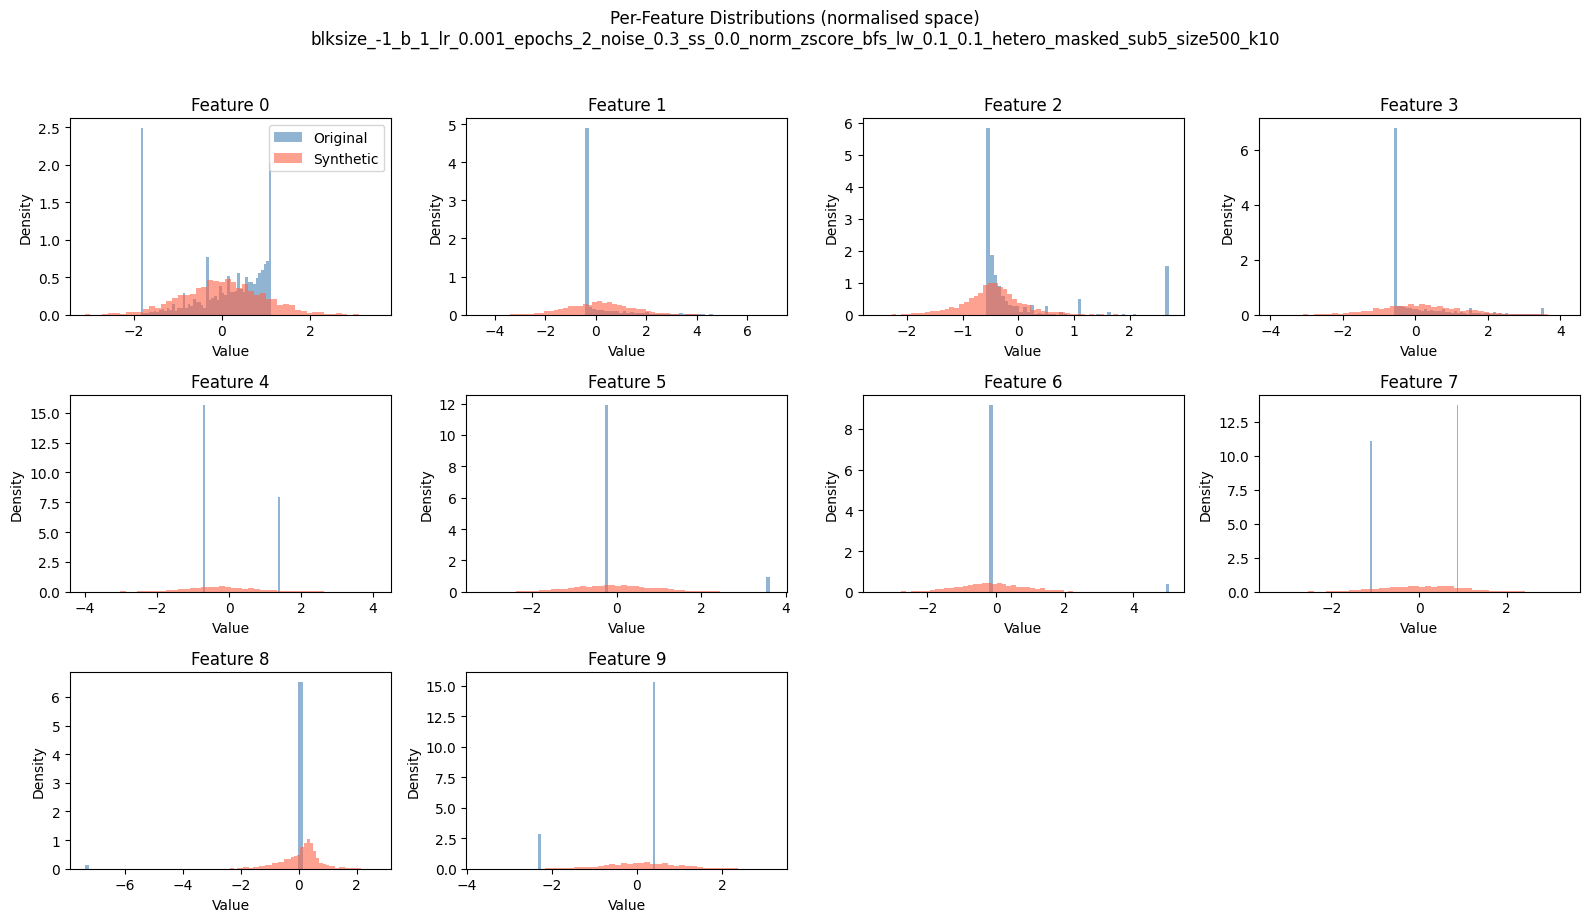

In [34]:
# Per-feature distribution plots
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i in range(feat_dim):
    ax = axes[i]
    ax.hist(org_feats_cmp[:, i], bins=50, alpha=0.6, label='Original',  color='steelblue', density=True)
    ax.hist(syn_feats_cmp[:, i], bins=50, alpha=0.6, label='Synthetic', color='tomato',    density=True)
    ax.set_title(f'Feature {i}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend()

for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Per-Feature Distributions ({mode_label} space)\n{run}', y=1.02)
plt.tight_layout()
plt.show()

## Subgraph Connectivity Check

Verifies that each synthetic subgraph is connected (or near-connected). Isolated nodes would indicate BFS expansion failed to reach all sampled nodes.

In [35]:
rows = []
for i, sg in enumerate(subgraphs):
    sg_nx = nx.Graph(sg.to_networkx())
    n_components = nx.number_connected_components(sg_nx)
    largest_cc = max(nx.connected_components(sg_nx), key=len)
    zero_deg = sum(1 for _, d in sg_nx.degree() if d == 0)
    rows.append({
        'Subgraph': f'subgraph_{i}',
        'Connected components': n_components,
        'Largest CC (nodes)': len(largest_cc),
        'Isolated nodes (deg=0)': zero_deg,
        'Status': 'OK' if n_components == 1 else f'FRAGMENTED ({n_components} components)',
    })

display(pd.DataFrame(rows).set_index('Subgraph'))

,Connected components,Largest CC (nodes),Isolated nodes (deg=0),Status
Subgraph,,,,
subgraph_0,1,500,0,OK
subgraph_1,1,500,0,OK
subgraph_2,1,500,0,OK
subgraph_3,1,500,0,OK
subgraph_4,1,500,0,OK
